# Following example program to familiarize with PyMC State Space Module

In this notebook I am following the example program porvided by Jesse Garbowski in the PyMC Labs webinar: [Time Series Analysis with Bayesian State Space Models in PyMC (YouTube)](https://www.youtube.com/watch?v=G9VWXZdbtKQ&t=2763s). 

I believe the best way to go about familiarizing the module was:-

- Firstly, to follow an example program exactly and get the similar output
- Seconly, try to make a custom State Space model following the documentation from the: `pymc-extras/notebooks/Making a custom Statespace Model.ipynb`

In [1]:
import sys
print(sys.executable)

C:\Users\Hridayesh\anaconda3\envs\pymc-newenv\python.exe


In [2]:
import numpyro
numpyro.set_host_device_count(4)
import pymc as pm
import pytensor
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import arviz as az
import pandas as pd

import warnings
warnings.filterwarnings('ignore', message='The RandomType SharedVariables')

plt.rcParams.update({'figure.figsize':(14, 4), 'figure.dpi': 144, 'axes.grid': True, 'grid.linewidth': 0.5, 'grid.linestyle': '--', 'axes.spines.top': False,
'axes.spines.bottom': False, 'axes.spines.left': False, 'axes.spines.right': False, 'figure.constrained_layout.use': True})

import numpy as np
seed = sum(map(ord, 'Why Statespace?'))
rng = np.random.default_rng()


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [4]:
def plot_timeseries_posterior(idata, data=None, ax=None, color='tab:blue', data_color='k', label=None):
    if ax is None:
        fig, ax = plt.subplots()
    
    mu = idata.mean(dim=['chain', 'draw'])
    hdi = az.hdi(idata)
    key = list(hdi.data_vars.keys())[0]
    hdi = hdi[key]
    
    x_values = mu.coords['time'].values
        
    ax.plot(x_values, mu, color=color, label=label)
    ax.fill_between(x_values, *hdi.values.T, alpha=0.25, color=color, label=f'{label} HDI 94%' if label is not None else None)
    
    if data is not None:
        ax.plot(x_values, data, color=data_color, ls='--', label='Data')
        
    if label is not None:
        ax.legend()

    return ax

## Model description

I will be following the same model of Auto-Regressive order 1 as the example, which is 
$$
x_t = g(x_{t-1}, \epsilon_t)
$$

with g as the **policy function** which explains how the state of the system $x_t$ is updated in regards to the previous state $x_{t-1}$. $\epsilon_t$ are the stocastic shocks. The model has the similar definition
$$
x_t = \rho x_{t-1}+ \epsilon_t
$$

Therefore, we have to deal with three parameters in this system, namely $\rho$, $\epsilon_t$ and $x_0$. $\rho$ is the parameter which describes the persistance of shocks, $x_0$ is the initial state of the system and $\epsilon_t$ as mentioned earlier are the stocastic shocks. $\epsilon_t$ is assumed to be iid Normal with 0 mean and variance as $\sigma^2$.

In [12]:
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import arviz as az
import pandas as pd
from pymc.pytensorf import collect_default_updates
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

time_idx = pd.date_range(start='2000-01-01', end='2024-08-01',freq='MS')
coords = {'time': time_idx}

with pm.Model(coords=coords) as ar1_model:
    # define prior -- stationary only please
    rho = pm.Beta('rho', alpha=1, beta=1)
    sigma = pm.Exponential('Sigma', lam=1)
    
    # define prior initial state
    x0 = pm.Normal('x0')
    
    # Make a wrapper fumction for pm.CustomDist that returns a random vector
    def ar1_dist(x0, rho, sigma, shape=None):
        
        # define a recursive relationship mapping x_{t-1} to x_t
        def step(x_tm1, rho, sigma):
            x_t = rho * x_tm1 + pm.Normal.dist(0, sigma)
            return x_t, collect_default_updates(x_t)
            
        sequence,updates= pytensor.scan(step, outputs_info=[x0], non_sequences=[rho, sigma], n_steps= len(ar1_model.coords['time']),strict=True)
        return sequence
        
    obs = pm.CustomDist('obs', x0, rho, sigma, dist=ar1_dist, dims=['time'])
    
    prior = pm.sample_prior_predictive(random_seed=rng)
    

Sampling: [Sigma, obs, rho, x0]


### Visualization

Now after the sampling, a random walk ``rng`` draw has been made from the samples and has been used for data visualization.

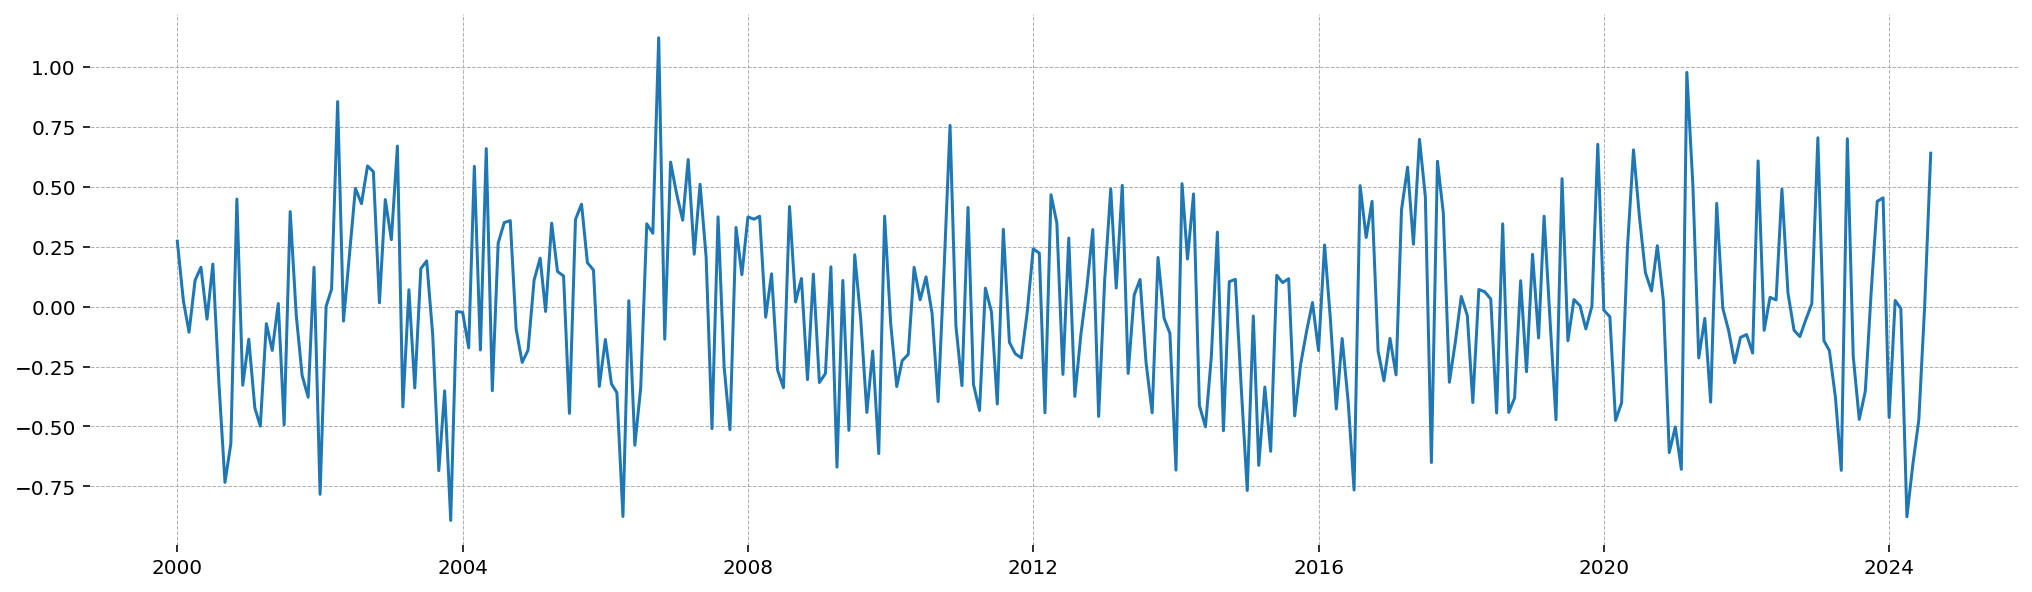

In [13]:
draw = rng.choice(500)
sample = pd.Series(prior.prior.obs.sel(chain=0, draw=draw),
                   index=time_idx)

true_params = [prior.prior[var].sel(chain=0, draw=draw) for var in ['x0', 'rho', 'Sigma']]
plt.plot(sample)

Next ``pm.observe()`` has been used to add the data back into the model as follows

In [19]:
warnings.filterwarnings("ignore",message=".*Scan return signature will change.*")
warnings.filterwarnings("ignore", category=RuntimeWarning)
with pm.observe(ar1_model, {'obs':sample}):
    idata=pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, Sigma, x0]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 80 seconds.


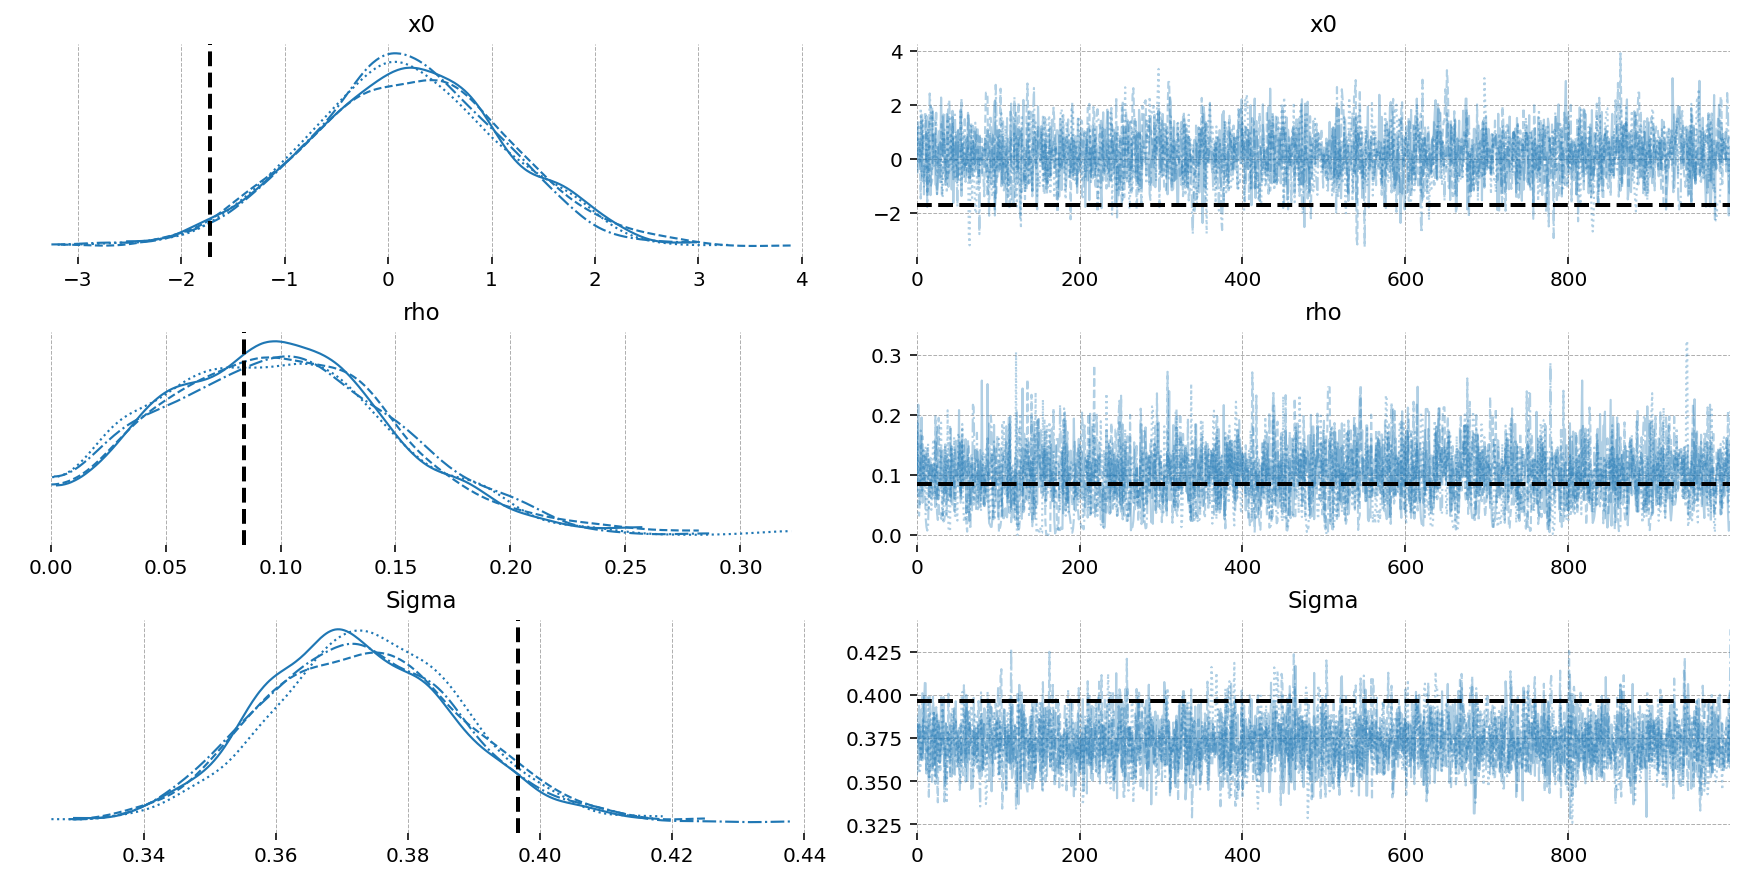

In [20]:
axes = az.plot_trace(idata, var_names = ['x0', 'rho', 'Sigma'])
for (axis, ref_val) in zip(axes[:, 0], true_params):
    axis.axvline(ref_val, c='k', lw=2, ls='--')
for (axis, ref_val) in zip(axes[:, 1], true_params):
    axis.axhline(ref_val, c='k', lw=2, ls='--')

We get such an output because this is the unconditional posterior predictive and not the condiotional counterpart. This is better illustrated below :-

In [21]:
with pm.observe(ar1_model, {'obs':sample}):
    idata = pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [obs]


Output()

<Axes: >

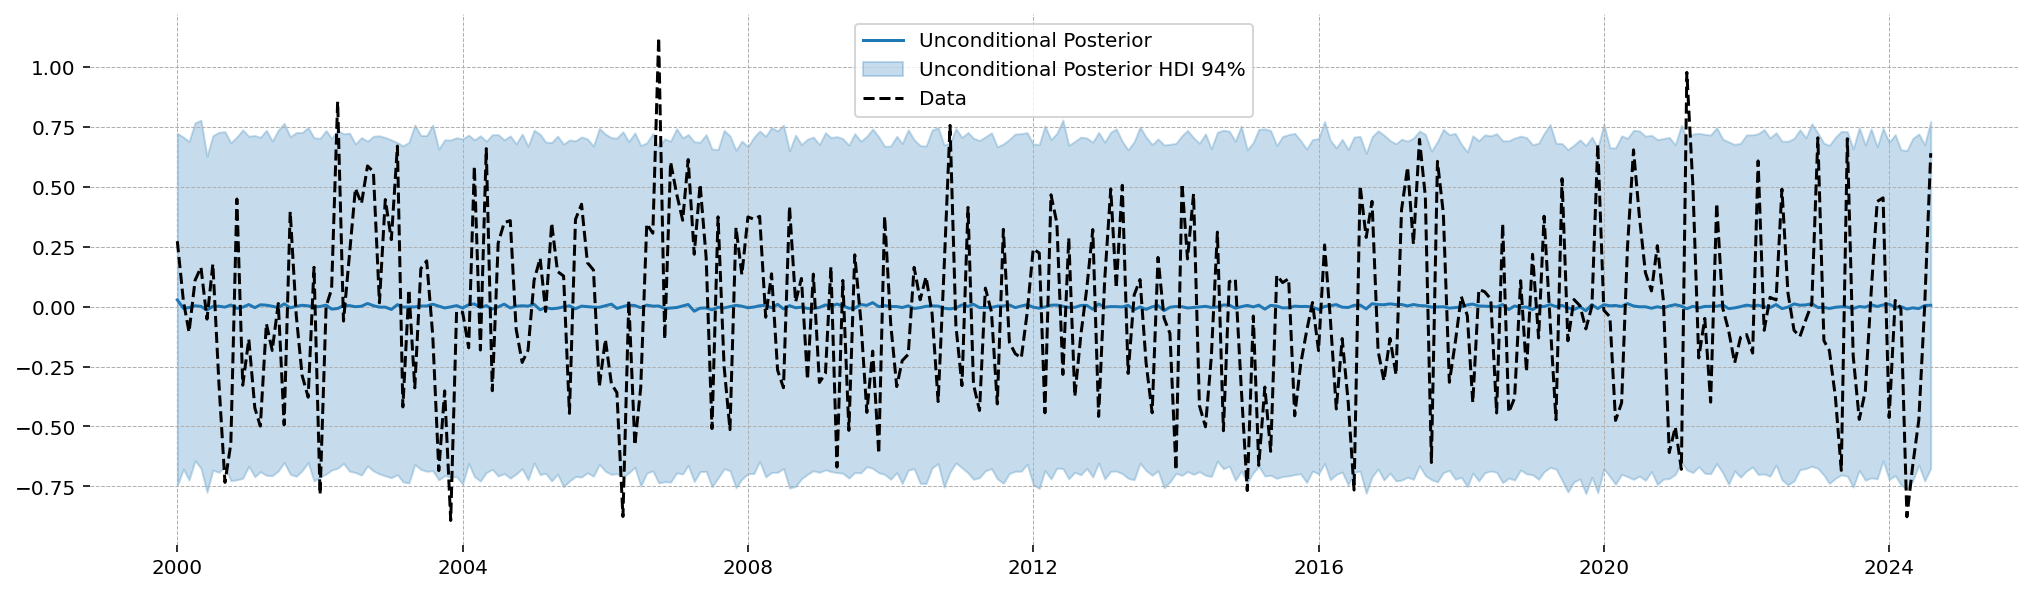

In [22]:
plot_timeseries_posterior(idata.posterior_predictive.obs, data=sample.values, label='Unconditional Posterior')

## Autoregressive of Order 1 using StateSapce

Now we use statespace in orfer to implement the model. ``BayesianSARIMAX`` model class form ``pymc_experimental.statespace`` has been used with one autoregereesive lag

In [23]:
import pymc as pm
import pymc_experimental
import numpyro
import jax
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

print(pm.__version__)
print(pymc_experimental.__version__)
print(numpyro.__version__)
print(jax.__version__)

5.19.1
0.1.4
0.13.2
0.4.35


In [24]:
import pymc_experimental.statespace as pmss
ss_mod = pmss.BayesianSARIMA(order=(1, 0, 0),  
                             seasonal_order=(0, 0, 0, 0), # the parameters are as follows (ar_lags, difference, ma_lags, season_period)
                             state_structure='fast',
                             stationary_initialization=True, 
                             measurement_error=False  
                            )

The following parameters should be assigned priors inside a PyMC model block: 
	ar_params -- shape: (1,), constraints: None, dims: ('ar_lag',)
	sigma_state -- shape: None, constraints: Positive, dims: None


### Why PyMCStateSpace

``pmss.BayesiansARIMA`` acts like a bridge between a full PyMC model and  a ready to use API like ``statsmodels.tsa.statespace``. 

Here we need to specify 2 variables namely ``ar_params`` which was represented as ``rho`` earlier and ``sigma_state`` which was represented by ``sigma`` above. We do not need to specify ``x0`` as ``stationary_initialization=True``.

In [25]:
with pm.Model(coords=ss_mod.coords) as ar1_ss_mod:
    pm.Beta('ar_params', 1, 1, dims=['ar_lag'])
    pm.Exponential('sigma_state', lam=1)
    
    # To look for these variables and create the model, the `build_statespace_graph` method has been called
    ss_mod.build_statespace_graph(data=sample, mode='JAX')

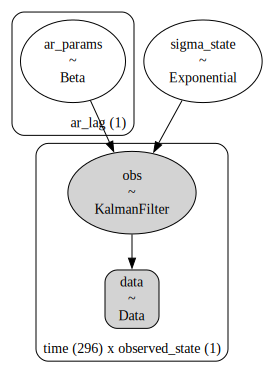

In [26]:
ar1_ss_mod.to_graphviz()  # In order to get a simplified graphical repersentation

In [29]:
with ar1_ss_mod:
    # Sampling with PyMCStateSpace
    idata_ss = pm.sample(nuts_sampler='numpyro', progressbar=False) #without the progressbar=False it was showing compatibility issues

As explained in the example, every statespace model has a ``coords`` property that gives the coordinates needed for the PyMC model. The can be viewed using the ``ss_mod.coords`` as below

In [30]:
ss_mod.coords

{'state': ['data'],
 'state_aux': ['data'],
 'observed_state': ['data'],
 'observed_state_aux': ['data'],
 'shock': ['innovation'],
 'shock_aux': ['innovation'],
 'ar_lag': [1]}

### ``ss_mod.build_statespace_garph``

This is very important for ``PyMCStateSapce``. Every statespace model comes with a set of symbolic matrices that describe how to build the system. ``ss_mod.build_statespace_garph`` is responsible for inserting PyMC ``RandomVariables`` into these matrices by matching on variable names.

The second thing that it does is it creates ``KalmanFilter`` and it uses it to compute the log likeihood of the provided data under the model. 

Without ``ss_mod.build_statespace_garph``, the model will be pointless. 

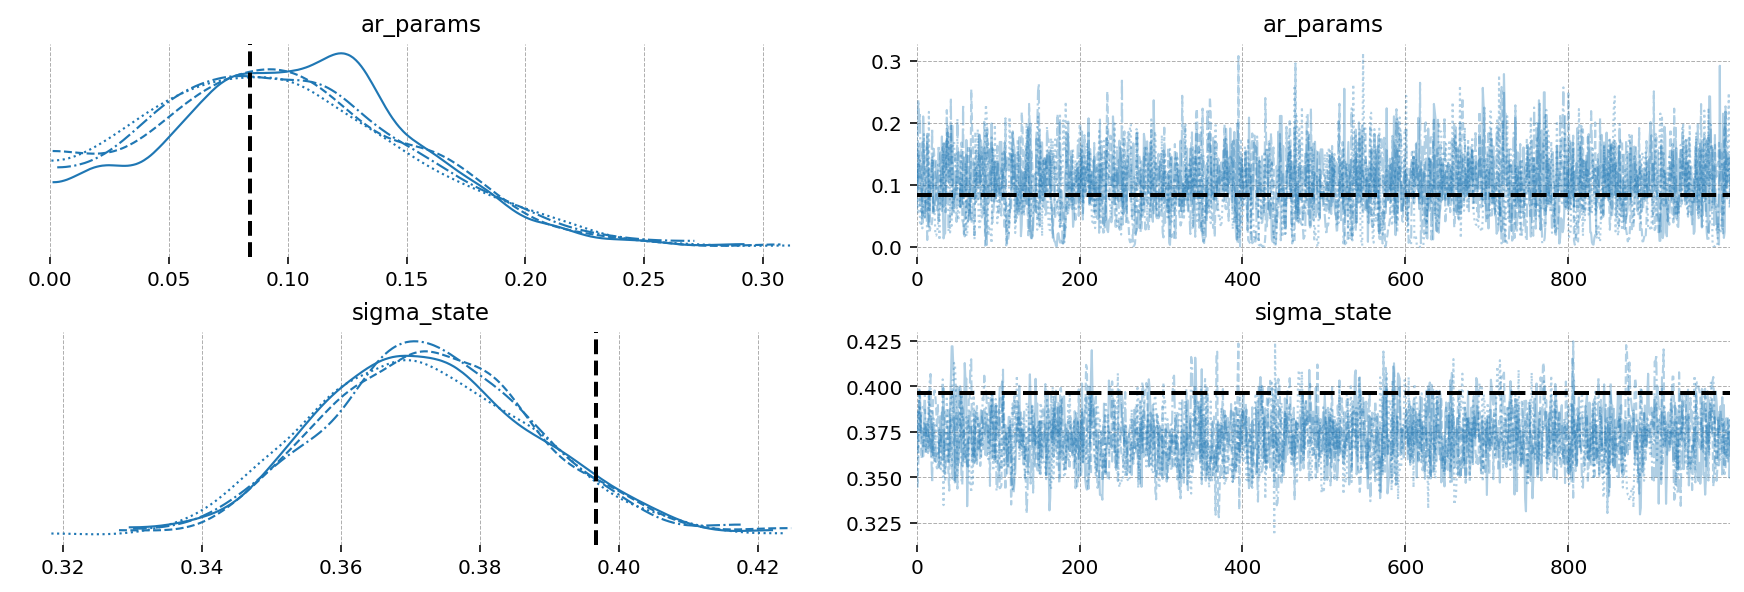

In [31]:
axes = az.plot_trace(idata_ss, var_names = ['ar_params', 'sigma_state'])
for (axis, ref_val) in zip(axes[:, 0], true_params[1:]):
    axis.axvline(ref_val, c='k', lw=2, ls='--')
for (axis, ref_val) in zip(axes[:, 1], true_params[1:]):
    axis.axhline(ref_val, c='k', lw=2, ls='--')
plt.show()

This shows us the sampling done via PyMCStateSapce

### Unconditional Posterior Predictive sampling

In [32]:
unconditional_post = ss_mod.sample_unconditional_posterior(idata_ss)

Sampling: [posterior_combined]


Output()

In [33]:
unconditional_post

<xarray.Dataset> Size: 19MB
Dimensions:             (chain: 4, draw: 1000, time: 296, state: 1,
                         observed_state: 1)
Coordinates:
  * chain               (chain) int32 16B 0 1 2 3
  * draw                (draw) int32 4kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
  * time                (time) datetime64[us] 2kB 2000-01-01 ... 2024-08-01
  * state               (state) <U4 16B 'data'
  * observed_state      (observed_state) <U4 16B 'data'
Data variables:
    posterior_latent    (chain, draw, time, state) float64 9MB 0.03347 ... 0....
    posterior_observed  (chain, draw, time, observed_state) float64 9MB 0.033...
Attributes:
    created_at:                 2026-03-30T17:54:32.038088+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.19.1

<Axes: >

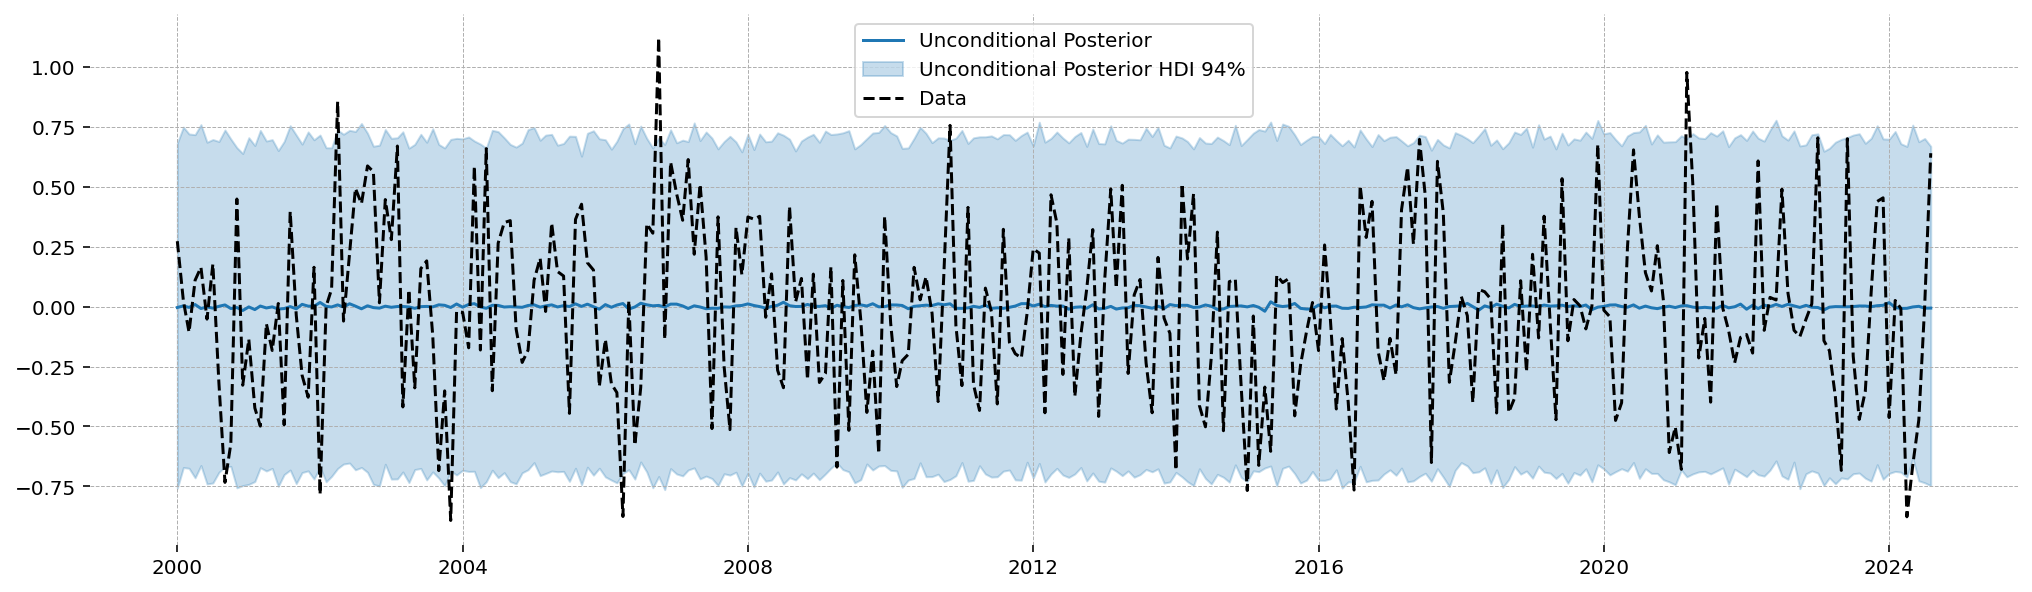

In [34]:
plot_timeseries_posterior(unconditional_post.posterior_observed.isel(observed_state=0), data=sample.values,label='Unconditional Posterior')

### Conditional Posterior Sampling

With PyMCStateSapce it is easy to also do the Conditional posterior sampling as follows :-

In [35]:
conditional_post = ss_mod.sample_conditional_posterior(idata_ss)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

In [36]:
conditional_post

<xarray.Dataset> Size: 57MB
Dimensions:                       (chain: 4, draw: 1000, time: 296, state: 1,
                                   observed_state: 1)
Coordinates:
  * chain                         (chain) int32 16B 0 1 2 3
  * draw                          (draw) int32 4kB 0 1 2 3 4 ... 996 997 998 999
  * time                          (time) datetime64[us] 2kB 2000-01-01 ... 20...
  * state                         (state) <U4 16B 'data'
  * observed_state                (observed_state) <U4 16B 'data'
Data variables:
    filtered_posterior            (chain, draw, time, state) float64 9MB 0.27...
    filtered_posterior_observed   (chain, draw, time, observed_state) float64 9MB ...
    predicted_posterior           (chain, draw, time, state) float64 9MB 0.75...
    predicted_posterior_observed  (chain, draw, time, observed_state) float64 9MB ...
    smoothed_posterior            (chain, draw, time, state) float64 9MB 0.27...
    smoothed_posterior_observed   (chain, draw, time, observed_state) float64 9MB ...
Attributes:
    created_at:                 2026-03-30T18:01:32.678665+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.19.1

<Axes: >

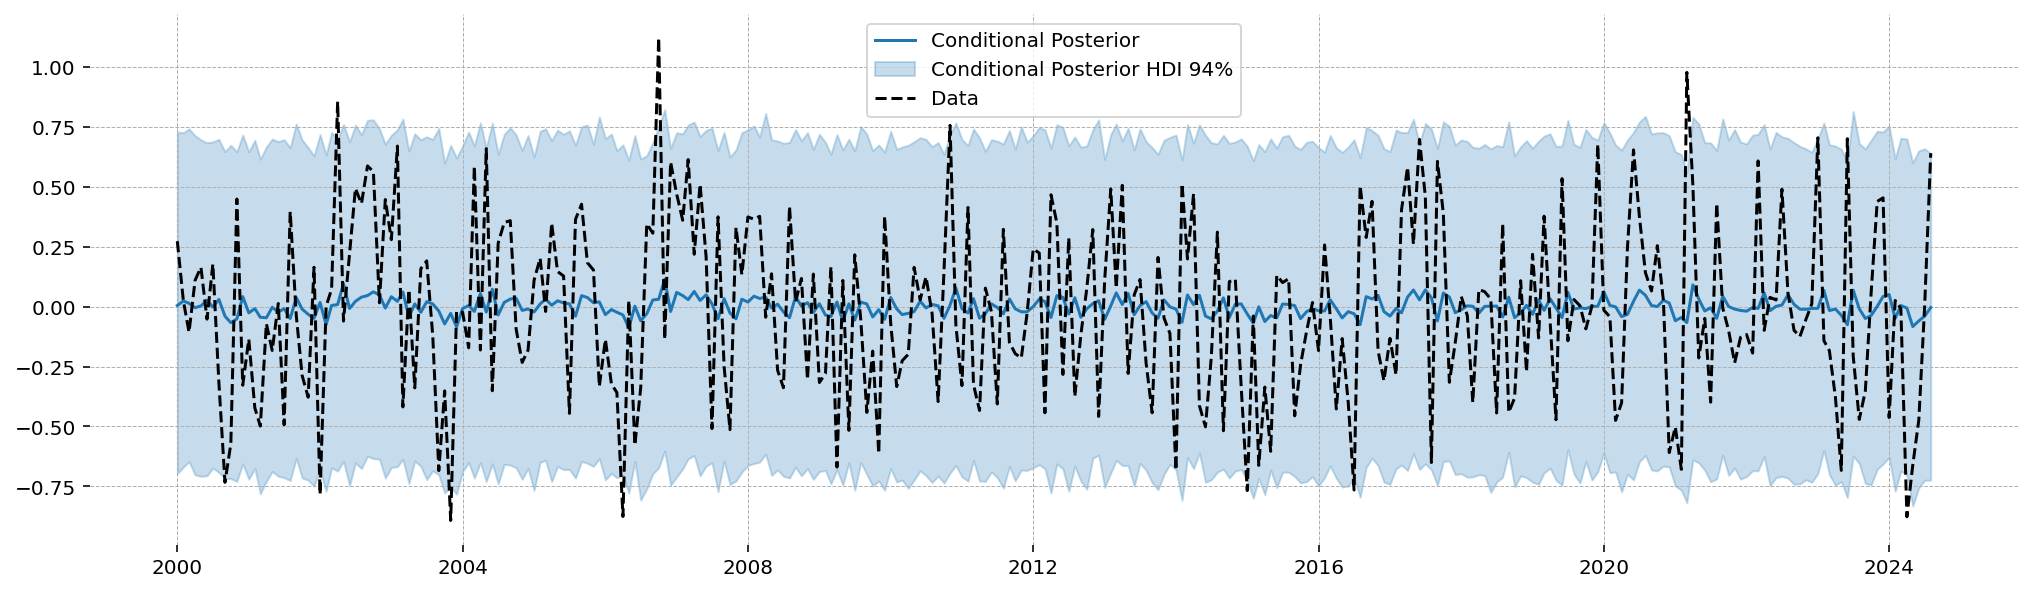

In [37]:
plot_timeseries_posterior(conditional_post.predicted_posterior_observed.isel(observed_state=0), data=sample.values, label='Conditional Posterior')

### Forecasting

This is pure PyMC with StateSpace handling the details in the `forecast` function. We just have to provide the:

1. Start date (by default the last value of the date index)
2. An End Date or The number of Periods|

In [38]:
idata_forecast = ss_mod.forecast(idata_ss, periods=50)

No start date provided. Using the last date in the data index. To silence this warning, explicitly pass a start date or set verbose = False
Sampling: [forecast_combined]


Output()

In [40]:
idata_forecast

<xarray.Dataset> Size: 3MB
Dimensions:            (chain: 4, draw: 1000, time: 50, state: 1,
                        observed_state: 1)
Coordinates:
  * chain              (chain) int32 16B 0 1 2 3
  * draw               (draw) int32 4kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
  * time               (time) datetime64[us] 400B 2024-09-01 ... 2028-10-01
  * state              (state) <U4 16B 'data'
  * observed_state     (observed_state) <U4 16B 'data'
Data variables:
    forecast_latent    (chain, draw, time, state) float64 2MB -0.1196 ... -0....
    forecast_observed  (chain, draw, time, observed_state) float64 2MB -0.119...
Attributes:
    created_at:                 2026-03-30T18:15:22.517896+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.19.1

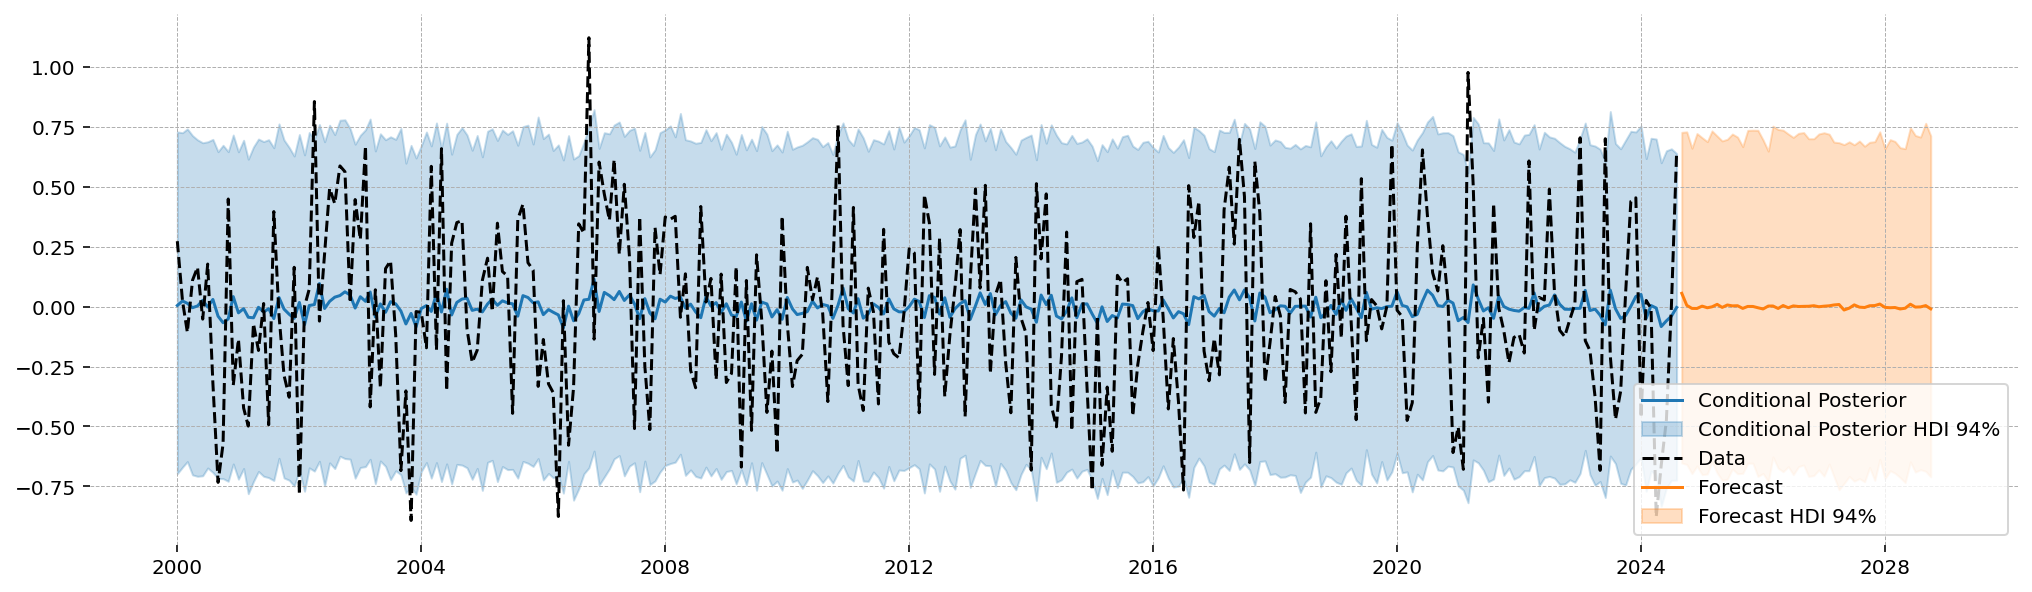

In [41]:
ax = plot_timeseries_posterior(conditional_post.predicted_posterior_observed.isel(observed_state=0), data=sample.values, label='Conditional Posterior')
ax = plot_timeseries_posterior(idata_forecast.forecast_observed.isel(observed_state=0), color='tab:orange', label='Forecast', ax=ax)